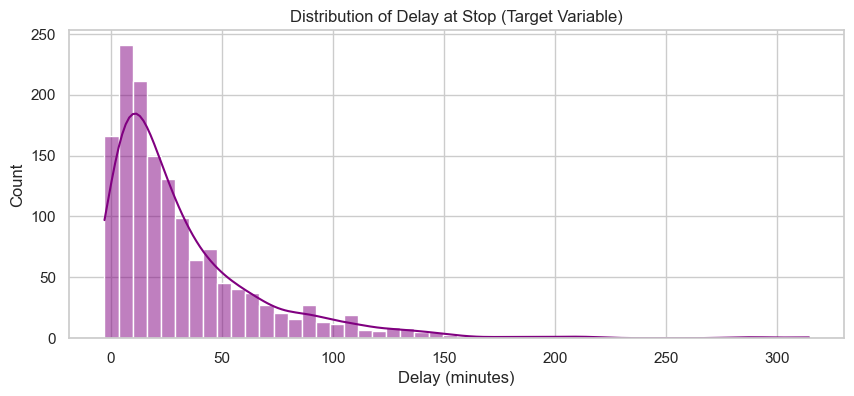

Target Variable Statistics:
count    1451.000000
mean       32.705238
std        37.262122
min        -2.900000
25%         8.400000
50%        20.300000
75%        43.800000
max       314.200000
Name: delay_at_stop_min, dtype: float64
--------------------------------------------------


C:\Users\fomav\AppData\Local\Temp\ipykernel_17684\2034618827.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_master, x='weather_condition', y='delay_at_stop_min', palette='Blues')


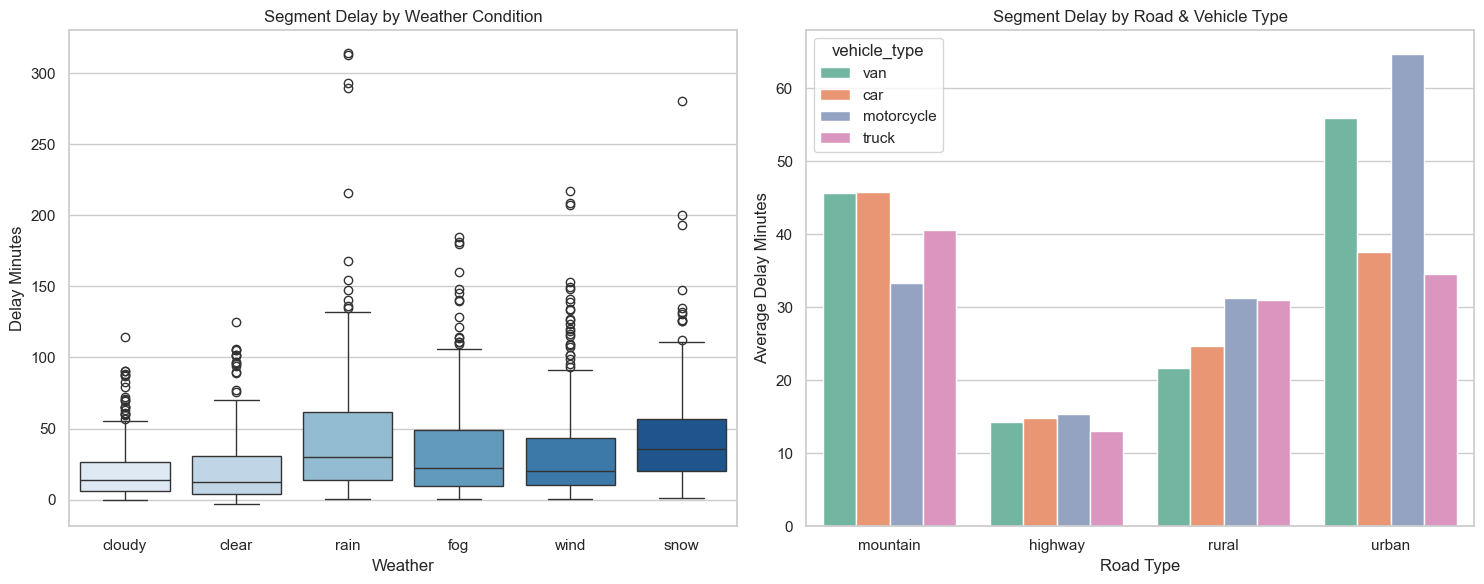

In [5]:
# 1. Target Variable Distribution (The most important chart)
plt.figure(figsize=(10, 4))
sns.histplot(df_master['delay_at_stop_min'], bins=50, kde=True, color='purple')
plt.title("Distribution of Delay at Stop (Target Variable)")
plt.xlabel("Delay (minutes)")
plt.show()

print("Target Variable Statistics:")
print(df_master['delay_at_stop_min'].describe())
print("-" * 50)

# 2. Contextual Charts
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df_master, x='weather_condition', y='delay_at_stop_min', palette='Blues')
plt.title("Segment Delay by Weather Condition")
plt.ylabel("Delay Minutes")
plt.xlabel("Weather")

plt.subplot(1, 2, 2)
sns.barplot(data=df_master, x='road_type', y='delay_at_stop_min', hue='vehicle_type', errorbar=None, palette='Set2')
plt.title("Segment Delay by Road & Vehicle Type")
plt.ylabel("Average Delay Minutes")
plt.xlabel("Road Type")

plt.tight_layout()
plt.show()

In [6]:
print("Executing Master Merge: Fusing Segment data with Route Context...")

# Merge the specific stops with the overarching route conditions
df_master = pd.merge(
    df_stops, 
    df_routes[['route_id', 'vehicle_type', 'weather_condition', 'traffic_level', 'road_incident', 'temperature_c']], 
    on='route_id', 
    how='left'
)

print(f"✅ Master Dataset Created! Shape: {df_master.shape}")

# The features our ML Engine will actually learn from
ml_features = ['route_id', 'stop_id', 'road_type', 'vehicle_type', 'weather_condition', 'traffic_level', 'road_incident', 'delay_at_stop_min']

print("\nNull check after merge (CRITICAL):")
print(df_master[ml_features].isnull().sum())

display(df_master[ml_features].head())

Executing Master Merge: Fusing Segment data with Route Context...
✅ Master Dataset Created! Shape: (1451, 25)

Null check after merge (CRITICAL):
route_id             0
stop_id              0
road_type            0
vehicle_type         0
weather_condition    0
traffic_level        0
road_incident        0
delay_at_stop_min    0
dtype: int64


,route_id,stop_id,road_type,vehicle_type,weather_condition,traffic_level,road_incident,delay_at_stop_min
0,RT-0001,STP-95181,mountain,van,cloudy,low,1,8.4
1,RT-0001,STP-38221,mountain,van,cloudy,low,1,15.1
2,RT-0001,STP-80284,mountain,van,cloudy,low,1,54.1
3,RT-0001,STP-19116,mountain,van,cloudy,low,1,31.0
4,RT-0001,STP-57819,mountain,van,cloudy,low,1,8.7


In [7]:
print("Converting timestamps from Text to Datetime objects...")

# Routes
df_routes['departure_planned'] = pd.to_datetime(df_routes['departure_planned'], errors='coerce')
df_routes['departure_actual'] = pd.to_datetime(df_routes['departure_actual'], errors='coerce')

# Stops
time_cols = ['planned_arrival', 'actual_arrival', 'time_window_open', 'time_window_close']
for col in time_cols:
    df_stops[col] = pd.to_datetime(df_stops[col], errors='coerce')

# Environmental
df_weather['timestamp'] = pd.to_datetime(df_weather['timestamp'], errors='coerce')
df_traffic['timestamp'] = pd.to_datetime(df_traffic['timestamp'], errors='coerce')

print("✅ Timestamps converted! Checking for parse failures (Nulls):")
print(df_stops[time_cols].isnull().sum())

Converting timestamps from Text to Datetime objects...
✅ Timestamps converted! Checking for parse failures (Nulls):
planned_arrival      0
actual_arrival       0
time_window_open     0
time_window_close    0
dtype: int64


In [8]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for our charts
sns.set_theme(style="whitegrid")

# Define paths
DATA_DIR = "../data"

# Load the Big 5 Datasets
print("Loading data into RAM...")
df_routes = pd.read_csv(os.path.join(DATA_DIR, "routes.csv"))
df_stops = pd.read_csv(os.path.join(DATA_DIR, "route_stops.csv"))
df_weather = pd.read_csv(os.path.join(DATA_DIR, "weather_observations.csv"))
df_traffic = pd.read_csv(os.path.join(DATA_DIR, "traffic_segments.csv"))
df_stats = pd.read_csv(os.path.join(DATA_DIR, "historical_delay_stats.csv"))

print(f"✅ Loaded {len(df_routes)} Routes")
print(f"✅ Loaded {len(df_stops)} Route Stops (Segments)")
print(f"✅ Loaded {len(df_weather)} Weather Observations")
print(f"✅ Loaded {len(df_traffic)} Traffic Segments")
print(f"✅ Loaded {len(df_stats)} Historical Delay Stats")

Loading data into RAM...
✅ Loaded 200 Routes
✅ Loaded 1451 Route Stops (Segments)
✅ Loaded 300 Weather Observations
✅ Loaded 500 Traffic Segments
✅ Loaded 480 Historical Delay Stats
